# PicoScope 3418E 고급 트리거 — pulse-width, analog window, delay

1.0·2.0은 채널 B의 상승 에지로 복합 연산 전체를 담은 뒤, 두 HIGH 펄스를 소프트웨어로
AES와 SHA로 자른다. 3418E는 같은 GPIO 선에서 펄스 폭 qualifier로 한 펄스만 고르거나,
채널 A EM 진폭이 idle 창을 나가는 순간을 트리거하거나, 첫 에지 이후 delay sample만큼
기다려 SHA 구간만 담을 수 있다.

배선을 바꾸지 않는다. analog 트리거를 쓰더라도 BNC B는 GPIO에 연결된 채로 두어,
아날로그가 연 창 안에 GPIO 펄스가 몇 개 들어왔는지를 검증 정본으로 쓴다.

## 배선 (이 노트북은 바꾸지 않는다)

| 신호 | 연결 |
|---|---|
| 션트/전력 | Lite 내장 측정 경로 + Husky Measure (Husky는 열지 않음) |
| 근접 자기장 | EM 프로브 → LANGER PA303 → PicoScope A (DC 50 Ω) |
| GPIO4/TRIG 10× | Lite 내장 트리거 + Husky USERIO D0 + PicoScope B (DC 1 MΩ). Pico B에서 약 0.35 V HIGH |
| GPIO4/TRIG 1× | Pico AUX (전면 왼쪽 추가 BNC). 약 3.3 V CMOS. 1채널 최고속 디지털 트리거 |
| 타겟 클럭 | Lite HS2 → CW308 CLKIN, 같은 신호를 Husky AUX MCX로 분기 |
| Pico C·D | **BNC 미연결.** 소프트웨어로만 켜서 ADC 인터리브를 잰다 |
| Pico AWG | 전면 오른쪽 추가 BNC. 사용하지 않음 |

PA303 출력은 Pico A의 DC 50 Ω으로 종단한다. SDK probe scale은 x1이다.

진폭 트리거는 데이터 의존일 수 있다. 큰 EM 버스트가 있는 입력만 트리거하면 수집 집합이
편향된다. 이 노트북은 고정 입력으로만 analog window를 시도하고, GPIO 에지와의 상대
시각을 표로 남긴다. AES와 SHA 펄스 폭이 `PULSE_WIDTH_GAP_US`보다 덜 갈리면
pulse-width 캡처는 실패가 아니라 **이 펌웨어에서 폭이 겹친다**는 측정으로 건너뛴다.
폭을 벌리려고 펌웨어를 고치지 않는다.

GPIO4 HIGH는 양 펄스다. PWQ는 상승으로 폭 타이머를 시작하고, 본 트리거는
`FALLING_LOWER`(아래 비교기)로 끝을 본다. pypicosdk `set_pulse_width_trigger`는
극성을 뒤집어 음 펄스를 기다린다. 같은 래퍼의 `SetTriggerChannelProperties`는
3000A leftover `auxOutputEnable`을 끼워 psospa auto-trigger를 0(무한 대기)으로
만든다. 이 노트북은 그 두 곳을 우회한다.


## 1. 실행 환경 준비

ChipWhisperer Docker 이미지에 없는 Pico Python wrapper와 native driver는
이 서브프로젝트의 `.runtime/`에만 고정 버전으로 준비한다.


In [1]:
import importlib
import os
import shutil
import subprocess
import sys
import urllib.request
from pathlib import Path

PROJECT_DIR = Path('/workspace/[extra] PicoScope')
if not PROJECT_DIR.is_dir():
    raise RuntimeError('이 노트북은 chipwhisperer-kor Docker의 /workspace에서 실행해야 합니다.')

RUNTIME_DIR = PROJECT_DIR / '.runtime'
LOCAL_PYTHON_DIR = RUNTIME_DIR / 'python'
PICO_DRIVER_ROOT = RUNTIME_DIR / 'picoscope'
PICO_DRIVER_LIB = PICO_DRIVER_ROOT / 'lib' / 'libpsospa.so'
DOWNLOAD_DIR = RUNTIME_DIR / 'downloads'
RUNTIME_DIR.mkdir(exist_ok=True)

PYPICOSDK_VERSION = '1.7.5'
PICO_DRIVER_PACKAGE = 'libpsospa_1.1.7-0r5994_amd64.deb'
PICO_DRIVER_URL = (
    'https://labs.picotech.com/picoscope7/debian/pool/main/libp/libpsospa/'
    + PICO_DRIVER_PACKAGE
)

if not (LOCAL_PYTHON_DIR / 'pypicosdk').is_dir():
    print(f'[준비] pypicosdk {PYPICOSDK_VERSION} 로컬 설치')
    subprocess.run(
        [
            sys.executable, '-m', 'pip', 'install', '--no-deps', '--no-cache-dir',
            '--target', str(LOCAL_PYTHON_DIR), f'pypicosdk=={PYPICOSDK_VERSION}',
        ],
        check=True,
    )

sys.path.insert(0, str(LOCAL_PYTHON_DIR))
importlib.invalidate_caches()

if not PICO_DRIVER_LIB.exists():
    print(f'[준비] {PICO_DRIVER_PACKAGE} 로컬 추출')
    DOWNLOAD_DIR.mkdir(exist_ok=True)
    package_path = DOWNLOAD_DIR / PICO_DRIVER_PACKAGE
    if not package_path.exists():
        request = urllib.request.Request(
            PICO_DRIVER_URL, headers={'User-Agent': 'curl/8.0'}
        )
        with urllib.request.urlopen(request) as response, package_path.open('wb') as output:
            shutil.copyfileobj(response, output)

    extract_dir = RUNTIME_DIR / 'driver-extract'
    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    extract_dir.mkdir()
    subprocess.run(['dpkg-deb', '-x', str(package_path), str(extract_dir)], check=True)
    source_root = extract_dir / 'opt' / 'picoscope'
    if not (source_root / 'lib').is_dir():
        raise RuntimeError(f'Pico driver 패키지 구조를 확인할 수 없습니다: {source_root}')
    if PICO_DRIVER_ROOT.exists():
        shutil.rmtree(PICO_DRIVER_ROOT)
    shutil.copytree(source_root, PICO_DRIVER_ROOT, symlinks=True)
    shutil.rmtree(extract_dir)

if not PICO_DRIVER_LIB.exists():
    raise RuntimeError(f'libpsospa 로딩 파일이 없습니다: {PICO_DRIVER_LIB}')

print('[✓] 노트북 전용 Pico 런타임 준비 완료')
print(f'    Python wrapper: {LOCAL_PYTHON_DIR}')
print(f'    Native driver: {PICO_DRIVER_LIB}')


[✓] 노트북 전용 Pico 런타임 준비 완료
    Python wrapper: /workspace/[extra] PicoScope/.runtime/python
    Native driver: /workspace/[extra] PicoScope/.runtime/picoscope/lib/libpsospa.so


## 2. 실험 설정과 공통 도구

`PULSE_WIDTH_GAP_US`는 AES·SHA 평균 폭 차이가 이 값 이상일 때만 hardware
qualifier를 시도하는 문턱이다. 샘플 간격과 GPIO 지터를 한 덩어리로 보기 위해
5 µs로 둔다. 값을 바꾸려면 이 셀만 고친다.


In [2]:
import ctypes
import hashlib
import random
import time
import warnings

import chipwhisperer as cw
import matplotlib.pyplot as plt

%matplotlib inline
import numpy as np
import pandas as pd
from Crypto.Cipher import AES
from IPython.display import display

import pypicosdk as psdk

psdk.override_directory(str(PICO_DRIVER_ROOT))


def _psospa_set_trigger_channel_properties(
    self, threshold_upper, hysteresis_upper, threshold_lower, hysteresis_lower,
    channel, aux_output_enable=0, auto_trigger_us=0,
):
    # psospa: autoTriggerMicroSeconds is the 4th argument.
    # pypicosdk 1.7.5 inserts 3000A auxOutputEnable so auto-trigger becomes 0.
    prop = psdk.PICO_TRIGGER_CHANNEL_PROPERTIES(
        threshold_upper, hysteresis_upper, threshold_lower, hysteresis_lower, channel,
    )
    self._call_attr_function(
        'SetTriggerChannelProperties',
        self.handle,
        ctypes.byref(prop),
        ctypes.c_int16(1),
        ctypes.c_uint32(int(auto_trigger_us)),
    )


psdk.psospa.set_trigger_channel_properties = _psospa_set_trigger_channel_properties

PLATFORM = 'CW308_STM32F3'
CRYPTO_TARGET = 'NONE'
SS_VER = 'SS_VER_2_1'
LITE_SERIAL_NUMBER = '44203120394d36433130322030313035'

FIRMWARE_DIR = PROJECT_DIR / 'simpleserial_main'
FIRMWARE_PATH = FIRMWARE_DIR / f'simpleserial-scope-compare-{PLATFORM}.hex'
BUILD_OPTIONS = (
    f'PLATFORM={PLATFORM}', f'CRYPTO_TARGET={CRYPTO_TARGET}', f'SS_VER={SS_VER}'
)

AES_KEY_BYTES = 16
MESSAGE_BYTES = 64
RESULT_BYTES = 48
FIXED_CAPTURES = 5
RANDOM_SEED = 1

PRETRIGGER_PERCENT = 10
CAPTURE_POST_MARGIN_US = 50.0
PICO_TRIGGER_THRESHOLD_MV = 150
PICO_AUTO_TRIGGER_US = 1_000_000
PICO_SURVEY_RATE_SPS = 5_000_000
PICO_SURVEY_SAMPLES = 100_000
PICO_VERTICAL_PREFLIGHTS = 10
PICO_VERTICAL_RAIL_LIMIT = 0.90
PICO_FORMAL_RAIL_LIMIT = 0.95

PA303_GAIN_DB = 30.0
PA303_VOLTAGE_GAIN = 10 ** (PA303_GAIN_DB / 20.0)
PICO_A_COUPLING = psdk.COUPLING.DC_50OHM
PICO_B_COUPLING = psdk.COUPLING.DC
PICO_B_RANGE = psdk.RANGE.V1
PICO_BANDWIDTH = psdk.BANDWIDTH_CH.BW_FULL
PICO_ADC_INPUT_SCALE = 1.0
PICO_DUMMY_COUPLING = psdk.COUPLING.DC
PICO_DUMMY_RANGE = psdk.RANGE.V1
PICO_A_RANGES = (
    (10, psdk.RANGE.mV10), (20, psdk.RANGE.mV20),
    (50, psdk.RANGE.mV50), (100, psdk.RANGE.mV100),
    (200, psdk.RANGE.mV200), (500, psdk.RANGE.mV500),
    (1_000, psdk.RANGE.V1), (2_000, psdk.RANGE.V2),
    (5_000, psdk.RANGE.V5),
)

FIXED_KEY = bytes(range(AES_KEY_BYTES))
FIXED_MESSAGE = bytes(range(MESSAGE_BYTES))
DISPLAY_ENVELOPE_POINTS = 4_000

plt.rcParams['figure.dpi'] = 110
print('[✓] 실험 설정 로드 완료')
print(f'    pypicosdk {getattr(psdk, "__version__", PYPICOSDK_VERSION)}')

N_WIDTH = 10
N_ANALOG = 5
PULSE_WIDTH_GAP_US = 5.0
print(f'    폭 측정 {N_WIDTH}회, analog {N_ANALOG}회, 분리 문턱 {PULSE_WIDTH_GAP_US} µs')


/usr/local/lib/python3.12/site-packages/chipwhisperer/capture/trace/TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


[✓] 실험 설정 로드 완료
    pypicosdk 1.7.5
    폭 측정 10회, analog 5회, 분리 문턱 5.0 µs


In [3]:
def my_fsr_cmd(target, cmd, scmd, data, payload_only=False):
    '''SimpleSerial 2.1 명령을 보내고 500 ms 안에 첫 응답을 반환한다.

    송신 전 남은 ACK를 버린다. 응답이 없으면 TimeoutError, 프레임 길이가
    잘못되면 ValueError를 발생시키며 UART 버퍼와 타겟 명령 상태를 변경한다.
    '''
    target.flush()
    target.send_cmd(cmd=cmd, scmd=ord(scmd), data=data)
    response = target.read_cmd(timeout=500)
    if response is None:
        raise TimeoutError(f'SimpleSerial 응답 없음: 0x{cmd:02x}/{scmd}')
    if len(response) < 3:
        raise ValueError(f'SimpleSerial 응답 프레임이 너무 짧습니다: {response!r}')
    payload_end = 3 + response[2]
    if len(response) < payload_end:
        raise ValueError(f'SimpleSerial 응답 길이가 올바르지 않습니다: {response!r}')
    return bytes(response[3:payload_end]) if payload_only else response


def reset_target(scope, delay=0.05):
    '''Lite nRST로 타겟을 재시작하고 UART가 준비될 시간을 확보한다.'''
    scope.io.nrst = 'low'
    time.sleep(delay)
    scope.io.nrst = 'high_z'
    time.sleep(delay)


def golden_result(key, message):
    '''AES-128(message[:16]) || SHA-256(message || AES 결과)를 반환한다.'''
    ciphertext = AES.new(bytes(key), AES.MODE_ECB).encrypt(bytes(message[:16]))
    digest = hashlib.sha256(bytes(message) + ciphertext).digest()
    return ciphertext + digest


def run_target_transaction(target, key, message, verify=True):
    '''입력을 저장하고 복합 연산을 실행한다.

    verify=True이면 48바이트 결과를 골든 모델과 비교해 반환한다.
    verify=False이면 0x83을 생략하고 None을 반환한다. 키·메시지는 이미
    타겟에 있을 때도 다시 쓴다. UART와 trigger pin 상태를 변경한다.
    '''
    if len(key) != AES_KEY_BYTES or len(message) != MESSAGE_BYTES:
        raise ValueError('키는 16바이트, 메시지는 64바이트여야 합니다.')
    if my_fsr_cmd(target, 0x81, 'k', key, True) != bytes(key):
        raise RuntimeError('타겟이 AES 키를 올바르게 되돌려주지 않았습니다.')
    if my_fsr_cmd(target, 0x81, 'm', message, True) != bytes(message):
        raise RuntimeError('타겟이 SHA 메시지를 올바르게 되돌려주지 않았습니다.')
    if my_fsr_cmd(target, 0x82, 'c', [], True) != b'\x01':
        raise RuntimeError('타겟 복합 연산 완료 응답이 올바르지 않습니다.')
    if not verify:
        return None
    result = my_fsr_cmd(target, 0x83, 'r', [], True)
    expected = golden_result(key, message)
    if result != expected:
        raise RuntimeError(
            'AES·SHA 골든 모델 불일치\n'
            f'타겟: {result.hex()}\n골든: {expected.hex()}'
        )
    return result


def fire_crypto_only(target):
    '''이미 저장된 키·메시지로 0x82/'c'만 실행한다. 결과는 회수하지 않는다.'''
    if my_fsr_cmd(target, 0x82, 'c', [], True) != b'\x01':
        raise RuntimeError('타겟 복합 연산 완료 응답이 올바르지 않습니다.')


def detect_trigger_pulses(time_us, trigger_mv, threshold_mv=PICO_TRIGGER_THRESHOLD_MV):
    '''Pico B에서 AES·SHA 두 HIGH 구간의 (시작, 끝) 시간을 반환한다.

    2 sample보다 짧은 교차는 잡음으로 버린다. 정확히 두 펄스가 아니면
    RuntimeError를 발생시킨다. 입력 배열은 변경하지 않는다.
    '''
    high = np.asarray(trigger_mv) >= threshold_mv
    edges = np.diff(high.astype(np.int8), prepend=0, append=0)
    starts = np.flatnonzero(edges == 1)
    ends = np.flatnonzero(edges == -1)
    pulses = [(int(s), int(e)) for s, e in zip(starts, ends) if e - s >= 2]
    if len(pulses) != 2:
        raise RuntimeError(
            f'Pico B에서 유효한 트리거 펄스 2개가 필요하지만 {len(pulses)}개를 검출했습니다.'
        )
    last = len(time_us) - 1
    return tuple(
        (float(time_us[s]), float(time_us[min(e, last)]))
        for s, e in pulses
    )


def channel_bit(channel):
    '''over-range 마스크에서 해당 아날로그 채널의 비트를 반환한다.'''
    return 1 << int(channel)


def envelope_xy(time_us, values, n_points=DISPLAY_ENVELOPE_POINTS):
    '''긴 파형을 pixel 구간 min/max로 줄인다. 통계용 원본은 호출측이 보존한다.'''
    time_us = np.asarray(time_us)
    values = np.asarray(values)
    if values.size <= n_points:
        return time_us, values, values
    edges = np.linspace(0, values.size, n_points + 1, dtype=int)
    t = np.empty(n_points)
    lo = np.empty(n_points)
    hi = np.empty(n_points)
    for i in range(n_points):
        sl = values[edges[i]:max(edges[i + 1], edges[i] + 1)]
        t[i] = time_us[edges[i]]
        lo[i] = float(np.min(sl))
        hi[i] = float(np.max(sl))
    return t, lo, hi


def wait_pico_ready(pico, timeout_s=5.0):
    # pypicosdk is_ready() has no timeout. Poll IsReady and fail instead of hanging USB.
    ready = ctypes.c_int16()
    fn = pico._get_attr_function('IsReady')
    deadline = time.time() + timeout_s
    last_status = 0
    while time.time() < deadline:
        last_status = int(fn(pico.handle, ctypes.byref(ready)))
        if last_status not in (0, 39, 407):
            pico._error_handler(last_status)
        if ready.value != 0:
            return
        time.sleep(0.05)
    try:
        pico.stop()
    except Exception:
        pass
    raise TimeoutError(
        f'Pico IsReady timed out after {timeout_s:.1f}s (status={last_status})'
    )


def configure_gpio_high_pulse_width(
    pico, timebase, samples, pw_type, time_upper_us, time_lower_us,
):
    # Positive GPIO HIGH: PWQ starts on RISING, main trigger ends on FALLING_LOWER.
    # Do not use set_pulse_width_trigger: it waits for a negative pulse.
    pico.set_trigger_channel_conditions(
        [
            (psdk.CHANNEL.B, psdk.TRIGGER_STATE.TRUE),
            (psdk.CHANNEL.PULSE_WIDTH_SOURCE, psdk.TRIGGER_STATE.TRUE),
        ]
    )
    pico.set_trigger_channel_directions(
        channel=psdk.CHANNEL.B,
        direction=psdk.THRESHOLD_DIRECTION.FALLING_LOWER,
        threshold_mode=psdk.THRESHOLD_MODE.LEVEL,
    )
    upper_adc, lower_adc, hyst_u, hyst_l = pico._thr_hyst_mv_to_adc(
        psdk.CHANNEL.B,
        float(PICO_TRIGGER_THRESHOLD_MV),
        float(PICO_TRIGGER_THRESHOLD_MV),
        20.0,
        20.0,
    )
    pico.set_trigger_channel_properties(
        threshold_upper=upper_adc, hysteresis_upper=hyst_u,
        threshold_lower=lower_adc, hysteresis_lower=hyst_l,
        channel=psdk.CHANNEL.B, auto_trigger_us=PICO_AUTO_TRIGGER_US,
    )
    interval_s = float(pico.get_timebase(timebase, samples)['Interval(ns)']) * 1e-9
    pw_upper = int((float(time_upper_us) / psdk.TIME_UNIT.US) / interval_s)
    pw_lower = int((float(time_lower_us) / psdk.TIME_UNIT.US) / interval_s)
    pico.set_pulse_width_qualifier_properties(
        lower=pw_lower, upper=pw_upper, pw_type=pw_type,
    )
    pico.set_pulse_width_qualifier_conditions(
        [(psdk.CHANNEL.B, psdk.TRIGGER_STATE.TRUE)]
    )
    pico.set_pulse_width_qualifier_directions(
        channel=psdk.CHANNEL.B,
        direction=psdk.THRESHOLD_DIRECTION.RISING,
        threshold_mode=psdk.THRESHOLD_MODE.LEVEL,
    )


def close_pico(pico):
    '''Pico block capture를 멈추고 USB handle을 해제한다.'''
    if pico is None:
        return
    try:
        pico.stop()
    except Exception:
        pass
    try:
        pico.close_unit()
    except Exception:
        pass
    # pypicosdk 1.7.5 destructor는 close 뒤에도 이전 handle을 다시 닫는다.
    try:
        pico.handle.value = 0
    except Exception:
        pass


def open_pico(serial_number, resolution, attempts=3):
    '''지정 해상도로 3418E를 연다. 채널은 아직 구성하지 않는다.

    USB 재열거 직후 Not Responding이 나오면 잠시 쉬고 다시 연다.
    '''
    last_exc = None
    for attempt in range(1, attempts + 1):
        pico = psdk.psospa()
        try:
            pico.open_unit(serial_number=serial_number, resolution=resolution)
            variant = pico.get_unit_info(psdk.UNIT_INFO.PICO_VARIANT_INFO)
            if variant != '3418E':
                raise RuntimeError(f'연결된 PicoScope가 3418E가 아닙니다: {variant}')
            return pico
        except Exception as exc:
            last_exc = exc
            print(f'    [!] Pico open {attempt}/{attempts}: {type(exc).__name__}: {exc}')
            close_pico(pico)
            time.sleep(3.0)
    raise last_exc


def enumerate_pico_serial():
    '''연결된 Pico가 정확히 한 대인지 확인하고 시리얼을 반환한다.'''
    probe = psdk.psospa()
    enumerated = probe.get_enumerated_units()
    pico_count = int(enumerated[0])
    serials = str(enumerated[1]).split(',') if len(enumerated) >= 2 else []
    serials = [item for item in serials if item]
    if pico_count != 1 or len(serials) != 1:
        raise RuntimeError(f'PicoScope 3418E 한 대만 연결해야 합니다: {enumerated!r}')
    return serials[0]


def configure_pico_channels(
    pico,
    vertical,
    enabled_channels,
    trigger='gpio_b',
    bandwidth=None,
    analog_window=None,
    auto_trigger_us=None,
):
    '''요청한 채널만 켜고 트리거를 건다.

    배선은 바꾸지 않는다. 채널 C·D를 켜도 BNC는 비어 있으며, 인터리브 몫을
    줄이기 위한 dummy enable이다. A의 DC 50 Ω은 1 MΩ으로 fallback하지 않는다.
    trigger='gpio_b'는 B(10× GPIO, 약 0.35 V)가 enabled에 있어야 한다.
    trigger='aux'는 전면 왼쪽 AUX의 1× GPIO(약 3.3 V CMOS)로 건다.
    trigger='analog_a_window'는 analog_window 딕셔너리(ADC-window mV)가 필요하다.
    auto_trigger_us=0은 무기한 대기이다.
    '''
    bandwidth = PICO_BANDWIDTH if bandwidth is None else bandwidth
    auto_trigger_us = PICO_AUTO_TRIGGER_US if auto_trigger_us is None else int(auto_trigger_us)
    enabled = set(enabled_channels)
    specs = {
        psdk.CHANNEL.A: (vertical['range_enum'], PICO_A_COUPLING, float(vertical['offset_v'])),
        psdk.CHANNEL.B: (PICO_B_RANGE, PICO_B_COUPLING, 0.0),
        psdk.CHANNEL.C: (PICO_DUMMY_RANGE, PICO_DUMMY_COUPLING, 0.0),
        psdk.CHANNEL.D: (PICO_DUMMY_RANGE, PICO_DUMMY_COUPLING, 0.0),
    }
    for channel, (range_enum, coupling, offset_v) in specs.items():
        if channel in enabled:
            # limiter는 측정 채널 A에만 건다. B는 GPIO, C·D는 dummy라 FULL을 유지한다.
            channel_bw = bandwidth if channel == psdk.CHANNEL.A else PICO_BANDWIDTH
            pico.set_channel(
                channel=channel, range=range_enum, enabled=True,
                coupling=coupling, offset=offset_v,
                bandwidth=channel_bw, probe_scale=PICO_ADC_INPUT_SCALE,
            )
        else:
            pico.set_channel(channel=channel, enabled=False)

    if trigger == 'gpio_b':
        if psdk.CHANNEL.B not in enabled:
            raise RuntimeError('GPIO 트리거는 채널 B가 켜져 있어야 합니다.')
        pico.set_simple_trigger(
            channel=psdk.CHANNEL.B,
            threshold=PICO_TRIGGER_THRESHOLD_MV,
            threshold_unit='mv',
            direction=psdk.TRIGGER_DIR.RISING,
            auto_trigger=auto_trigger_us,
        )
        return

    if trigger == 'analog_a_window':
        if analog_window is None:
            raise RuntimeError('analog_a_window 트리거에 analog_window가 필요합니다.')
        auto_ms = 0 if auto_trigger_us == 0 else max(1, auto_trigger_us // 1000)
        pico.set_advanced_trigger(
            channel=psdk.CHANNEL.A,
            state=psdk.TRIGGER_STATE.TRUE,
            direction=psdk.THRESHOLD_DIRECTION.EXIT,
            threshold_mode=psdk.THRESHOLD_MODE.WINDOW,
            threshold_upper_mv=float(analog_window['upper_mv']),
            threshold_lower_mv=float(analog_window['lower_mv']),
            hysteresis_upper_mv=float(analog_window['hyst_mv']),
            hysteresis_lower_mv=float(analog_window['hyst_mv']),
            auto_trigger_ms=auto_ms,
        )
        return


    if trigger == 'aux':
        pico.set_aux_io_mode(psdk.AUXIO_MODE.INPUT)
        pico.set_simple_trigger(
            channel=psdk.CHANNEL.TRIGGER_AUX,
            threshold=0,
            threshold_unit='adc',
            direction=psdk.TRIGGER_DIR.RISING,
            auto_trigger=auto_trigger_us,
        )
        return

    if trigger == 'none':
        pico.set_simple_trigger(
            channel=psdk.CHANNEL.A, threshold=0, enable=False, auto_trigger=auto_trigger_us,
        )
        return

    raise ValueError(f'알 수 없는 trigger: {trigger}')


def arm_pico(pico, samples, pretrigger_percent, timebase=None):
    '''현재 켠 채널의 버퍼를 등록하고 비동기 block capture를 시작한다.

    timebase가 None이면 현재 채널 마스크에서 가능한 최속 timebase를 쓴다.
    '''
    if timebase is None:
        fastest = pico.get_minimum_timebase_stateless()
        timebase = int(fastest['timebase'])
    actual_interval_s = float(pico.get_timebase(timebase, samples)['Interval(ns)']) * 1e-9
    actual_rate = 1.0 / actual_interval_s
    buffers = pico.set_data_buffer_for_enabled_channels(samples)
    pico.run_block_capture(timebase, samples, pretrigger_percent)
    return {
        'buffers': buffers,
        'timebase': timebase,
        'samples': samples,
        'pretrigger_percent': pretrigger_percent,
        'sample_rate_sps': actual_rate,
        'sample_interval_s': actual_interval_s,
    }


def read_pico(pico, armed, a_offset_v, ratio=0, ratio_mode=None):
    '''완료를 기다린 뒤 A(와 있으면 B) 파형을 독립 배열로 반환한다.

    pypicosdk adc_to_mv는 analog offset을 복원하지 않는다. a_adc_window_mv는
    ADC rail 판정용이고 a_mv는 입력에 더해진 offset을 빼 복원한 물리 입력이다.
    C·D dummy 채널은 반환하지 않는다. over_range_mask는 장비 원본 마스크다.
    '''
    if ratio_mode is None:
        ratio_mode = psdk.RATIO_MODE.RAW
    wait_pico_ready(pico, timeout_s=max(3.0, PICO_AUTO_TRIGGER_US / 1e6 + 2.0))
    actual_samples = pico.get_values(
        armed['samples'], ratio=ratio, ratio_mode=ratio_mode, wait_for_ready=False,
    )
    raw = {}
    for channel, buffer in armed['buffers'].items():
        raw[channel] = np.asarray(buffer[:actual_samples]).copy()
    converted = pico.adc_to_mv(raw)
    time_us = pico.get_time_axis(
        armed['timebase'], actual_samples,
        pre_trig_percent=armed['pretrigger_percent'], unit='us', ratio=ratio,
    )
    a_adc_window_mv = np.asarray(converted[psdk.CHANNEL.A], dtype=float)
    record = {
        'time_us': np.asarray(time_us, dtype=float),
        'a_adc_window_mv': a_adc_window_mv,
        'a_mv': a_adc_window_mv - float(a_offset_v) * 1_000.0,
        'sample_rate_sps': armed['sample_rate_sps'] / max(1, ratio),
        'over_range_mask': int(getattr(pico, 'over_range', 0)),
        'actual_samples': int(actual_samples),
        'timebase': armed['timebase'],
        'ratio': int(ratio),
    }
    if psdk.CHANNEL.B in converted:
        record['b_mv'] = np.asarray(converted[psdk.CHANNEL.B], dtype=float)
    else:
        record['b_mv'] = None
    return record


def get_pico_offset_limits(pico):
    '''3418E model JSON에서 X1·DC 50 Ω range별 analog offset 한계를 반환한다.'''
    details = pico.get_variant_details('3418E', buffer_size=131_072)
    limits = {}
    for full_scale_mv, _ in PICO_A_RANGES:
        expected_nv = int(full_scale_mv * 1_000_000)
        for setting in details['RangeSettings']:
            for probe in setting['ProbeSettings']:
                if (
                    int(probe['Type']) != int(psdk.PICO_PROBE_RANGE_INFO.X1_PROBE_NV)
                    or int(probe['Max']) != expected_nv
                    or int(probe['Min']) != -expected_nv
                ):
                    continue
                match = next(
                    (
                        item for item in probe['OffsetLimits']
                        if int(item['Coupling']) == int(PICO_A_COUPLING)
                    ),
                    None,
                )
                if match is not None:
                    limits[full_scale_mv] = (float(match['Min']), float(match['Max']))
        if full_scale_mv not in limits:
            raise RuntimeError(
                f'3418E의 ±{full_scale_mv:g} mV·DC 50 Ω offset 한계가 없습니다.'
            )
    return limits


def choose_pico_vertical(records, offset_limits, minimum_full_scale_mv=0):
    '''PA303 출력 min/max에 10% rail 여유를 주는 최소 range·offset을 고른다.'''
    global_min_mv = min(float(np.min(record['a_mv'])) for record in records)
    global_max_mv = max(float(np.max(record['a_mv'])) for record in records)
    target_offset_v = -(global_min_mv + global_max_mv) / 2_000.0
    for full_scale_mv, range_enum in PICO_A_RANGES:
        if full_scale_mv < minimum_full_scale_mv:
            continue
        minimum_v, maximum_v = offset_limits[full_scale_mv]
        offset_v = float(np.clip(target_offset_v, minimum_v, maximum_v))
        centered = np.asarray([global_min_mv, global_max_mv], dtype=float) + offset_v * 1_000.0
        rail_fraction = float(np.max(np.abs(centered)) / full_scale_mv)
        if rail_fraction <= PICO_VERTICAL_RAIL_LIMIT:
            return {
                'range_enum': range_enum,
                'full_scale_mv': float(full_scale_mv),
                'offset_v': offset_v,
                'coupling': 'DC 50 Ω',
                'bandwidth': 'FULL',
                'probe_scale': PICO_ADC_INPUT_SCALE,
                'signal_path': 'EM probe → LANGER PA303 → PicoScope A',
                'pa303_gain_db': PA303_GAIN_DB,
                'selection_min_mv': global_min_mv,
                'selection_max_mv': global_max_mv,
                'selection_rail_fraction': rail_fraction,
            }
    raise RuntimeError(
        'Pico A 사전 파형을 DC 50 Ω의 지원 range·offset 안에 넣을 수 없습니다: '
        f'{global_min_mv:.3f}–{global_max_mv:.3f} mV'
    )


def summarize_pico_vertical(records, vertical, resolution_bits):
    '''PA303 출력/ADC-window 수직 통계를 사용자 표시용으로 반환한다.'''
    rows = []
    for index, record in enumerate(records):
        physical = record['a_mv']
        adc_window = record['a_adc_window_mv']
        rows.append({
            'trace': index + 1,
            'min_mv': float(np.min(physical)),
            'max_mv': float(np.max(physical)),
            'peak_to_peak_mv': float(np.ptp(physical)),
            'rail_fraction': float(np.max(np.abs(adc_window)) / vertical['full_scale_mv']),
            'a_over_range': int(bool(record['over_range_mask'] & channel_bit(psdk.CHANNEL.A))),
        })
    per_trace = pd.DataFrame(rows)
    peak_to_peak_mv = float(per_trace['max_mv'].max() - per_trace['min_mv'].min())
    rail_fraction = float(per_trace['rail_fraction'].max())
    utilization = peak_to_peak_mv / (2.0 * vertical['full_scale_mv'])
    return {
        'per_trace': per_trace,
        'global_min_mv': float(per_trace['min_mv'].min()),
        'global_max_mv': float(per_trace['max_mv'].max()),
        'peak_to_peak_mv': peak_to_peak_mv,
        'utilization': utilization,
        'rail_fraction': rail_fraction,
        'headroom': 1.0 - rail_fraction,
        'adc_lsb_uv': (
            2.0 * vertical['full_scale_mv'] * 1_000.0 / (2 ** resolution_bits - 1)
        ),
        'over_range_count': int(per_trace['a_over_range'].sum()),
    }


def analog_window_from_record(record, vertical):
    '''GPIO 정렬 파형에서 A ADC-window의 idle 대역을 추정한다.

    첫 트리거 펄스 이전 구간을 idle로 본다. 창을 너무 좁히면 잡음이 바로
    EXIT하고, 너무 넓히면 암호 EM이 창을 못 나간다. idle 표준편차의 8배와
    full scale의 3% 중 큰 값을 반폭으로 쓴다.
    '''
    pulses = detect_trigger_pulses(record['time_us'], record['b_mv'])
    idle_end = max(int(np.searchsorted(record['time_us'], pulses[0][0]) - 8), 32)
    idle = np.asarray(record['a_adc_window_mv'][:idle_end], dtype=float)
    centre = float(np.median(idle))
    idle_std = float(np.std(idle))
    half = max(8.0 * idle_std, 0.03 * float(vertical['full_scale_mv']))
    hyst = max(2.0 * idle_std, 0.005 * float(vertical['full_scale_mv']))
    return {
        'center_mv': centre,
        'upper_mv': centre + half,
        'lower_mv': centre - half,
        'hyst_mv': hyst,
        'idle_std_mv': idle_std,
        'idle_end_us': float(record['time_us'][idle_end - 1]),
    }


def samples_for_window(sample_rate_sps, window_end_us, pretrigger_percent=PRETRIGGER_PERCENT):
    '''물리 윈도우를 담는 sample 수. 100 단위로 올림한다.'''
    total_us = (window_end_us + CAPTURE_POST_MARGIN_US) / (1.0 - pretrigger_percent / 100.0)
    samples = int(np.ceil(sample_rate_sps * total_us * 1e-6 / 100.0) * 100)
    return max(samples, 1_000)


def build_firmware():
    '''simpleserial_main을 clean 후 빌드한다. HEX가 없으면 실패한다.'''
    subprocess.run(['make', *BUILD_OPTIONS, 'clean'], cwd=FIRMWARE_DIR, check=True)
    subprocess.run(['make', *BUILD_OPTIONS], cwd=FIRMWARE_DIR, check=True)
    if not FIRMWARE_PATH.is_file():
        raise RuntimeError(f'펌웨어 HEX가 생성되지 않았습니다: {FIRMWARE_PATH}')


def clean_firmware():
    '''빌드 산출물을 지운다. 실패해도 실험 예외를 가리지 않는다.'''
    clean = subprocess.run(
        ['make', *BUILD_OPTIONS, 'clean'], cwd=FIRMWARE_DIR,
        stdout=subprocess.DEVNULL, stderr=subprocess.PIPE, text=True,
    )
    if clean.returncode == 0:
        print('  [✓] 펌웨어 빌드 산출물 정리')
    else:
        print(f'  [!] 펌웨어 clean 경고: {clean.stderr.strip()}')


def capture_one(
    pico, target, vertical, key, message, enabled_channels, trigger,
    samples, analog_window=None, bandwidth=None, auto_trigger_us=None,
    verify=True, timebase=None, ratio=0, ratio_mode=None,
):
    '''한 트랜잭션을 arm → 실행 → 읽기. A over-range만 실패로 본다.'''
    configure_pico_channels(
        pico, vertical, enabled_channels, trigger=trigger,
        bandwidth=bandwidth, analog_window=analog_window,
        auto_trigger_us=auto_trigger_us,
    )
    armed = arm_pico(pico, samples, PRETRIGGER_PERCENT, timebase=timebase)
    result = run_target_transaction(target, key, message, verify=verify)
    record = read_pico(
        pico, armed, vertical['offset_v'], ratio=ratio, ratio_mode=ratio_mode,
    )
    record['result'] = result
    record['enabled_channels'] = tuple(int(ch) for ch in enabled_channels)
    record['trigger'] = trigger
    if record['b_mv'] is not None:
        try:
            record['pulses_us'] = detect_trigger_pulses(record['time_us'], record['b_mv'])
        except RuntimeError:
            # analog window may open on EM without two GPIO pulses; keep the trace.
            if trigger != 'analog_a_window':
                raise
            record['pulses_us'] = None
    else:
        record['pulses_us'] = None
    if record['over_range_mask'] & channel_bit(psdk.CHANNEL.A):
        raise RuntimeError(
            f'PicoScope A over-range mask={record["over_range_mask"]}'
        )
    rail = float(np.max(np.abs(record['a_adc_window_mv'])) / vertical['full_scale_mv'])
    if rail > PICO_FORMAL_RAIL_LIMIT:
        raise RuntimeError(f'PicoScope A rail 점유율이 95%를 넘었습니다: {rail:.1%}')
    record['rail_fraction'] = rail
    return record


_synthetic_limits = {
    full_scale_mv: ((-0.25, 0.25) if full_scale_mv <= 200 else (-2.5, 2.5))
    for full_scale_mv, _ in PICO_A_RANGES
}
_synthetic_vertical = choose_pico_vertical(
    [{'a_mv': np.asarray([309.0, 329.0])}], _synthetic_limits
)
assert _synthetic_vertical['full_scale_mv'] == 100.0
assert _synthetic_vertical['offset_v'] == -0.25
del _synthetic_limits, _synthetic_vertical
print('[✓] 공통 도구 로드 완료')


[✓] 공통 도구 로드 완료


## 3. 장비 연결, 펄스 폭, analog window, trigger delay

고급 트리거 비교의 시간 정본은 20 MS/s 2채널이다. 5 GS/s가 필요하면 3.0이 채널 수를
먼저 닫는다. pulse-width는 GPIO HIGH 양 펄스(PWQ 상승 + 본 트리거 FALLING_LOWER)로
걸고, psospa auto-trigger 4인자 ABI를 쓴다. 캡처가 예상과 다르면 표의 error 칸에 남긴다.


In [4]:
def run_hardware_experiment():
    '''하드웨어 실험을 실행하고 연결이 모두 닫힌 결과 딕셔너리를 반환한다.'''
    lite_scope = None
    target = None
    pico = None
    experiment = None

    try:
        print('=== 1/N 펌웨어 clean build ===')
        build_firmware()

        print('\n=== 2/N Lite 연결 ===')
        lite_scope = cw.scope(sn=LITE_SERIAL_NUMBER)
        print('Husky는 배선에 남아 있어도 이 노트북은 USB handle을 열지 않는다.')

        print('\n=== 3/N 타겟 프로그램과 골든 모델 점검 ===')
        lite_scope.default_setup()
        target = cw.target(lite_scope, cw.targets.SimpleSerial2)
        cw.program_target(
            lite_scope, cw.programmers.STM32FProgrammer, str(FIRMWARE_PATH),
        )
        reset_target(lite_scope)
        target.flush()
        fixed_result = run_target_transaction(target, FIXED_KEY, FIXED_MESSAGE)
        target_clock_hz = float(lite_scope.clock.clkgen_freq)
        print('[✓] AES-128·SHA-256 결과 == 호스트 골든 모델')
        print(f'    AES: {fixed_result[:16].hex()}')
        print(f'    SHA: {fixed_result[16:].hex()}')
        print(f'    Lite clkgen {target_clock_hz:,.0f} Hz (Husky freq_ctr로 재지 않음)')

        print('\n=== 4/N PicoScope 연결, AES·SHA 시간창과 A 수직축 ===')
        # STM32 플래시가 같은 USB 트리를 흔든다. 열거만 되면 OpenUnit이
        # Not Found 인 경우가 있어, 실제로 열린 뒤에만 다음 단계로 간다.
        pico_serial = None
        last_exc = None
        for wait in range(25):
            try:
                pico_serial = enumerate_pico_serial()
                pico = open_pico(pico_serial, '10bit', attempts=2)
                last_exc = None
                break
            except Exception as exc:
                last_exc = exc
                print(f'    [!] Pico ready {wait+1}/25: {type(exc).__name__}: {exc}')
                close_pico(pico)
                pico = None
                time.sleep(4.0)
        if pico is None:
            raise last_exc
        pico_variant = pico.get_unit_info(psdk.UNIT_INFO.PICO_VARIANT_INFO)
        identity = pd.DataFrame(
            [
                ('ChipWhisperer-Lite', LITE_SERIAL_NUMBER, '프로그래밍·UART·타깃 클럭'),
                (f'PicoScope {pico_variant}', pico_serial, 'A=PA303 EM, B=GPIO 10×, AUX=GPIO 1×, C·D 미배선'),
            ],
            columns=['장비', '시리얼', '역할'],
        )
        display(identity)
        range_by_full_scale = dict(PICO_A_RANGES)
        broad_vertical = {
            'range_enum': range_by_full_scale[2_000],
            'full_scale_mv': 2_000.0,
            'offset_v': 0.0,
        }
        offset_limits = get_pico_offset_limits(pico)

        def reopen_10bit(reason):
            nonlocal pico
            print(f'    [!] Pico handle 복구: {reason}')
            close_pico(pico)
            time.sleep(2.0)
            pico = open_pico(pico_serial, '10bit', attempts=5)

        def is_transient(exc):
            msg = str(exc).lower()
            return any(
                token in msg
                for token in (
                    '50ohm', 'overvoltage', 'not responding',
                    'invalid handle', 'not found', 'timeout',
                )
            )

        def hardy_capture(*args, **kwargs):
            last_exc = None
            for attempt in range(1, 4):
                try:
                    return capture_one(pico, *args, **kwargs)
                except Exception as exc:
                    last_exc = exc
                    print(f'    [!] capture {attempt}/3: {type(exc).__name__}: {exc}')
                    if (not is_transient(exc)) or attempt == 3:
                        raise
                    reopen_10bit('capture')
            raise last_exc

        def survey(vertical):
            # NearestSampleIntervalStateless는 켠 채널이 있어야 한다.
            configure_pico_channels(
                pico, vertical, (psdk.CHANNEL.A, psdk.CHANNEL.B), 'gpio_b',
            )
            timebase = pico.sample_rate_to_timebase(
                PICO_SURVEY_RATE_SPS, unit=psdk.SAMPLE_RATE.SPS
            )
            return hardy_capture(
                target, vertical, FIXED_KEY, FIXED_MESSAGE,
                (psdk.CHANNEL.A, psdk.CHANNEL.B), 'gpio_b',
                PICO_SURVEY_SAMPLES, auto_trigger_us=PICO_AUTO_TRIGGER_US,
                timebase=timebase,
            )

        survey_record = survey(broad_vertical)
        if survey_record['over_range_mask'] & channel_bit(psdk.CHANNEL.A):
            broad_vertical = {
                'range_enum': range_by_full_scale[5_000],
                'full_scale_mv': 5_000.0,
                'offset_v': 0.0,
            }
            survey_record = survey(broad_vertical)
        aes_pulse, sha_pulse = survey_record['pulses_us']
        if not (aes_pulse[0] < aes_pulse[1] < sha_pulse[0] < sha_pulse[1]):
            raise RuntimeError(f'AES·SHA trigger 순서가 올바르지 않습니다: {survey_record["pulses_us"]}')
        window_end_us = sha_pulse[1]
        print(
            f'[✓] AES {aes_pulse[1] - aes_pulse[0]:.3f} µs, '
            f'SHA {sha_pulse[1] - sha_pulse[0]:.3f} µs, '
            f'창 끝 {window_end_us:.3f} µs'
        )

        preflight_rate = 20_000_000.0
        preflight_samples = samples_for_window(preflight_rate, window_end_us)
        preflight_timebase = pico.sample_rate_to_timebase(
            preflight_rate, unit=psdk.SAMPLE_RATE.SPS
        )
        rng = random.Random(RANDOM_SEED)
        discovery_inputs = [
            (
                bytes(rng.randrange(256) for _ in range(AES_KEY_BYTES)),
                bytes(rng.randrange(256) for _ in range(MESSAGE_BYTES)),
            )
            for _ in range(PICO_VERTICAL_PREFLIGHTS)
        ]
        discovery = []
        for index, (key, message) in enumerate(discovery_inputs):
            discovery.append(hardy_capture(
                target, broad_vertical, key, message,
                (psdk.CHANNEL.A, psdk.CHANNEL.B), 'gpio_b',
                preflight_samples, timebase=preflight_timebase,
            ))
            print(f'    수직축 탐색 {index + 1}/{PICO_VERTICAL_PREFLIGHTS}')
        pico_vertical = choose_pico_vertical(discovery, offset_limits)
        validation = []
        for index, (key, message) in enumerate(discovery_inputs):
            validation.append(hardy_capture(
                target, pico_vertical, key, message,
                (psdk.CHANNEL.A, psdk.CHANNEL.B), 'gpio_b',
                preflight_samples, timebase=preflight_timebase,
            ))
            print(f'    수직축 검증 {index + 1}/{PICO_VERTICAL_PREFLIGHTS}')
        validation_summary = summarize_pico_vertical(validation, pico_vertical, 10)
        if validation_summary['over_range_count'] != 0:
            raise RuntimeError('수직축 검증 파형에서 A over-range가 있습니다.')
        if validation_summary['rail_fraction'] > PICO_VERTICAL_RAIL_LIMIT:
            raise RuntimeError('수직축 검증이 rail 여유 10%를 만족하지 않습니다.')
        analog_window = analog_window_from_record(validation[0], pico_vertical)
        print(
            f'[✓] A ±{pico_vertical["full_scale_mv"]:g} mV, offset {pico_vertical["offset_v"]:.4f} V, '
            f'rail {validation_summary["rail_fraction"]:.1%}'
        )
        print(
            f'[✓] analog window {analog_window["lower_mv"]:.2f}–{analog_window["upper_mv"]:.2f} mV '
            f'(ADC-window)'
        )

        print('\n=== 5/N GPIO 펄스 폭 분포 ===')
        close_pico(pico)
        pico = open_pico(pico_serial, '10bit')
        configure_pico_channels(
            pico, pico_vertical, (psdk.CHANNEL.A, psdk.CHANNEL.B), trigger='gpio_b',
        )
        fastest = pico.get_minimum_timebase_stateless()
        rate_sps = 1.0 / float(fastest['time_interval'])
        # 고급 트리거 비교는 펄스 폭을  reliably 재는 것이 목적이므로
        # 2채널 최고속 전체가 아니라 20 MS/s로 창을 넉넉히 담는다.
        measure_rate = min(rate_sps, 20_000_000.0)
        measure_tb = pico.sample_rate_to_timebase(measure_rate, unit=psdk.SAMPLE_RATE.SPS)
        measure_rate = float(pico.get_actual_sample_rate())
        full_samples = samples_for_window(measure_rate, window_end_us)
        width_records = []
        for index in range(N_WIDTH):
            rec = hardy_capture(
                target, pico_vertical, FIXED_KEY, FIXED_MESSAGE,
                (psdk.CHANNEL.A, psdk.CHANNEL.B), 'gpio_b', full_samples,
                timebase=measure_tb,
            )
            aes_w = rec['pulses_us'][0][1] - rec['pulses_us'][0][0]
            sha_w = rec['pulses_us'][1][1] - rec['pulses_us'][1][0]
            width_records.append({
                'aes_width_us': aes_w,
                'sha_width_us': sha_w,
                'gap_us': rec['pulses_us'][1][0] - rec['pulses_us'][0][1],
                'record': rec,
            })
            print(f'    폭 측정 {index + 1}/{N_WIDTH}: AES {aes_w:.3f} µs, SHA {sha_w:.3f} µs')
        aes_widths = np.asarray([row['aes_width_us'] for row in width_records])
        sha_widths = np.asarray([row['sha_width_us'] for row in width_records])
        aes_mean, sha_mean = float(np.mean(aes_widths)), float(np.mean(sha_widths))
        gap = abs(sha_mean - aes_mean)
        separable = gap >= PULSE_WIDTH_GAP_US
        midpoint_us = 0.5 * (aes_mean + sha_mean)
        print(
            f'[✓] AES {aes_mean:.3f}±{np.std(aes_widths):.3f} µs, '
            f'SHA {sha_mean:.3f}±{np.std(sha_widths):.3f} µs, '
            f'간격 {gap:.3f} µs, pulse-width 분리 {separable}'
        )

        pw_captures = {'aes_only': [], 'sha_only': []}
        pw_errors = {}
        if separable:
            shorter, longer = ('aes_only', 'sha_only') if aes_mean < sha_mean else ('sha_only', 'aes_only')
            # psospa LESS_THAN/GREATER_THAN use `lower` as the threshold (samples).
            # `upper` is only for IN_RANGE/OUT_OF_RANGE. Midpoint must go in time_lower.
            specs = [
                (shorter, psdk.PULSE_WIDTH_TYPE.LESS_THAN, 0.0, midpoint_us),
                (longer, psdk.PULSE_WIDTH_TYPE.GREATER_THAN, 0.0, midpoint_us),
            ]
            for name, pw_type, time_upper, time_lower in specs:
                for attempt in range(1, 4):
                    try:
                        configure_pico_channels(
                            pico, pico_vertical, (psdk.CHANNEL.A, psdk.CHANNEL.B),
                            trigger='none',
                        )
                        configure_gpio_high_pulse_width(
                            pico, measure_tb, full_samples, pw_type, time_upper, time_lower,
                        )
                        pw_captures[name] = []
                        for index in range(FIXED_CAPTURES):
                            armed = arm_pico(pico, full_samples, PRETRIGGER_PERCENT, timebase=measure_tb)
                            run_target_transaction(target, FIXED_KEY, FIXED_MESSAGE)
                            rec = read_pico(pico, armed, pico_vertical['offset_v'])
                            rec['pulses_us'] = None
                            rec['n_b_pulses'] = 0
                            if rec['b_mv'] is not None:
                                high = rec['b_mv'] >= PICO_TRIGGER_THRESHOLD_MV
                                rec['n_b_pulses'] = int(
                                    np.sum(np.diff(high.astype(np.int8), prepend=0) == 1)
                                )
                                if rec['n_b_pulses'] == 2:
                                    rec['pulses_us'] = detect_trigger_pulses(
                                        rec['time_us'], rec['b_mv']
                                    )
                            pw_captures[name].append(rec)
                            print(f'    {name} {index + 1}/{FIXED_CAPTURES}')
                        pw_errors.pop(name, None)
                        break
                    except Exception as exc:
                        pw_errors[name] = f'{type(exc).__name__}: {exc}'
                        print(f'    [!] {name} {attempt}/3: {pw_errors[name]}')
                        try:
                            close_pico(pico)
                            time.sleep(2.0)
                            pico = open_pico(pico_serial, '10bit', attempts=5)
                        except Exception as open_exc:
                            print(f'    [!] Pico reopen 실패: {type(open_exc).__name__}: {open_exc}')
                            break
                        msg = str(exc).lower()
                        if attempt < 3 and (
                            '50ohm' in msg or 'overvoltage' in msg
                            or 'not responding' in msg or 'invalid handle' in msg
                            or 'not found' in msg or 'timeout' in msg
                        ):
                            continue
                        break
        else:
            print('[!] AES·SHA 펄스 폭이 충분히 갈리지 않아 pulse-width 캡처를 건너뛴다.')

        print('\n=== 6/N A analog window 트리거 (B는 검증용으로 계속 켬) ===')
        analog_captures = []
        analog_error = ''
        for attempt in range(1, 4):
            try:
                close_pico(pico)
                time.sleep(2.0)
                pico = open_pico(pico_serial, '10bit', attempts=5)
                analog_captures = []
                for index in range(N_ANALOG):
                    analog_captures.append(capture_one(
                        pico, target, pico_vertical, FIXED_KEY, FIXED_MESSAGE,
                        (psdk.CHANNEL.A, psdk.CHANNEL.B), 'analog_a_window',
                        full_samples, analog_window=analog_window, timebase=measure_tb,
                    ))
                    print(f'    analog window {index + 1}/{N_ANALOG}')
                analog_error = ''
                break
            except Exception as exc:
                analog_error = f'{type(exc).__name__}: {exc}'
                print(f'    [!] analog window {attempt}/3: {analog_error}')
                msg = str(exc).lower()
                if attempt < 3 and (
                    '50ohm' in msg or 'overvoltage' in msg
                    or 'not responding' in msg or 'invalid handle' in msg
                    or 'not found' in msg or 'timeout' in msg
                ):
                    continue
                break

        print('\n=== 7/N trigger delay로 SHA 구간만 ===')
        delay_captures = []
        delay_error = ''
        delay_samples = int(max(aes_pulse[1] * 1e-6 * measure_rate, 0))
        try:
            close_pico(pico)
            time.sleep(1.5)
            pico = open_pico(pico_serial, '10bit', attempts=5)
            # capture_one은 set_simple_trigger를 다시 호출해 delay를 지울 수 있다.
            sha_samples = samples_for_window(measure_rate, window_end_us - aes_pulse[1])
            for index in range(FIXED_CAPTURES):
                configure_pico_channels(
                    pico, pico_vertical, (psdk.CHANNEL.A, psdk.CHANNEL.B), trigger='gpio_b',
                )
                pico.set_trigger_delay(delay_samples)
                armed = arm_pico(
                    pico, sha_samples, PRETRIGGER_PERCENT, timebase=measure_tb,
                )
                run_target_transaction(target, FIXED_KEY, FIXED_MESSAGE)
                rec = read_pico(pico, armed, pico_vertical['offset_v'])
                delay_captures.append(rec)
                print(f'    delay {index + 1}/{FIXED_CAPTURES}')
            pico.set_trigger_delay(0)
        except Exception as exc:
            delay_error = f'{type(exc).__name__}: {exc}'
            print(f'    [!] trigger delay 실패: {delay_error}')
            try:
                if pico is not None:
                    pico.set_trigger_delay(0)
            except Exception:
                pass

        experiment = {
            'identity': identity,
            'pico_vertical': pico_vertical,
            'analog_window': analog_window,
            'survey': {
                'aes_pulse_us': aes_pulse,
                'sha_pulse_us': sha_pulse,
                'window_end_us': window_end_us,
            },
            'target_clock_hz': target_clock_hz,
            'measure_rate_sps': measure_rate,
            'widths': pd.DataFrame(
                [{k: v for k, v in row.items() if k != 'record'} for row in width_records]
            ),
            'aes_mean_us': aes_mean,
            'sha_mean_us': sha_mean,
            'width_gap_us': gap,
            'separable': separable,
            'midpoint_us': midpoint_us,
            'pw_captures': pw_captures,
            'pw_errors': pw_errors,
            'analog_captures': analog_captures,
            'analog_error': analog_error,
            'delay_captures': delay_captures,
            'delay_error': delay_error,
            'delay_samples': delay_samples,
            'width_examples': [row['record'] for row in width_records[:2]],
        }
        print('\n[✓] 고급 트리거 실험 완료')
    finally:
        print('\n장비와 빌드 자원 정리 중...')
        close_pico(pico)
        pico = None
        print('  [✓] PicoScope 연결 해제')
        if target is not None:
            try:
                target.dis()
                print('  [✓] SimpleSerial target 연결 해제')
            except Exception as exc:
                print(f'  [!] target 해제 경고: {exc}')
        if lite_scope is not None:
            try:
                lite_scope.dis()
                print('  [✓] Lite 연결 해제')
            except Exception as exc:
                print(f'  [!] Lite 해제 경고: {exc}')
        clean_firmware()

    if experiment is None:
        raise RuntimeError('실험 결과가 생성되지 않았습니다.')
    return experiment


EXPERIMENT = run_hardware_experiment()


=== 1/N 펌웨어 clean build ===
SS_VER set to SS_VER_2_1
SS_VER set to SS_VER_2_1
.
Welcome to another exciting ChipWhisperer target build!!
.
Cleaning project:
rm -f -- simpleserial-scope-compare-CW308_CC2538.hex simpleserial-scope-compare-CW301_AVR.hex simpleserial-scope-compare-CW303.hex simpleserial-scope-compare-CW304.hex simpleserial-scope-compare-CW308_MEGARF.hex simpleserial-scope-compare-CW308_SAM4L.hex simpleserial-scope-compare-CW308_STM32F0.hex simpleserial-scope-compare-CW308_STM32F1.hex simpleserial-scope-compare-CW308_STM32F2.hex simpleserial-scope-compare-CW308_STM32F3.hex simpleserial-scope-compare-CW308_STM32F4.hex simpleserial-scope-compare-CW308_K24F.hex simpleserial-scope-compare-CW308_NRF52.hex simpleserial-scope-compare-CW308_AURIX.hex simpleserial-scope-compare-CW308_SAML11.hex simpleserial-scope-compare-CW308_EFM32TG11B.hex simpleserial-scope-compare-CWLITEARM.hex simpleserial-scope-compare-CWLITEXMEGA.hex simpleserial-scope-compare-CWNANO.hex simpleserial-scope-co

-e Done!
.
Compiling:
-en     ../../iut/tiny-AES-c/aes.c ...


-e Done!
.
Compiling:
-en     ../../base/crypto/mbedtls/library/sha256.c ...


-e Done!
.
Compiling:
-en     ../../base/./simpleserial/simpleserial.c ...


-e Done!
.
Compiling:
-en     ../../base/./hal/hal.c ...
-e Done!
.
Compiling:
-en     ../../base/./hal//stm32f3/stm32f3_hal.c ...
-e Done!
.
Compiling:
-en     ../../base/./hal//stm32f3/stm32f3_hal_lowlevel.c ...


...

    analog window 4/5


    analog window 5/5

=== 7/N trigger delay로 SHA 구간만 ===


    delay 1/5
    delay 2/5
    delay 3/5
    delay 4/5


    delay 5/5

[✓] 고급 트리거 실험 완료

장비와 빌드 자원 정리 중...


  [✓] PicoScope 연결 해제
  [✓] SimpleSerial target 연결 해제
  [✓] Lite 연결 해제
  [✓] 펌웨어 빌드 산출물 정리


## 4. GPIO 펄스 폭

펌웨어는 AES HIGH, 짧은 LOW, SHA HIGH를 낸다. 두 HIGH의 폭이 충분히 갈려야
`LESS_THAN` / `GREATER_THAN`이 한 알고리즘만 고른다.


,aes_width_us,sha_width_us,gap_us
count,10.000,10.000,10.000
mean,1114.001,963.678,36.158
std,0.024,0.000,0.000
min,1113.966,963.678,36.158
25%,1113.979,963.678,36.158
50%,1114.016,963.678,36.158
75%,1114.016,963.678,36.158
max,1114.016,963.678,36.158


AES mean 1114.001 µs, SHA mean 963.678 µs, 간격 150.323 µs, 분리 True, midpoint 1038.840 µs


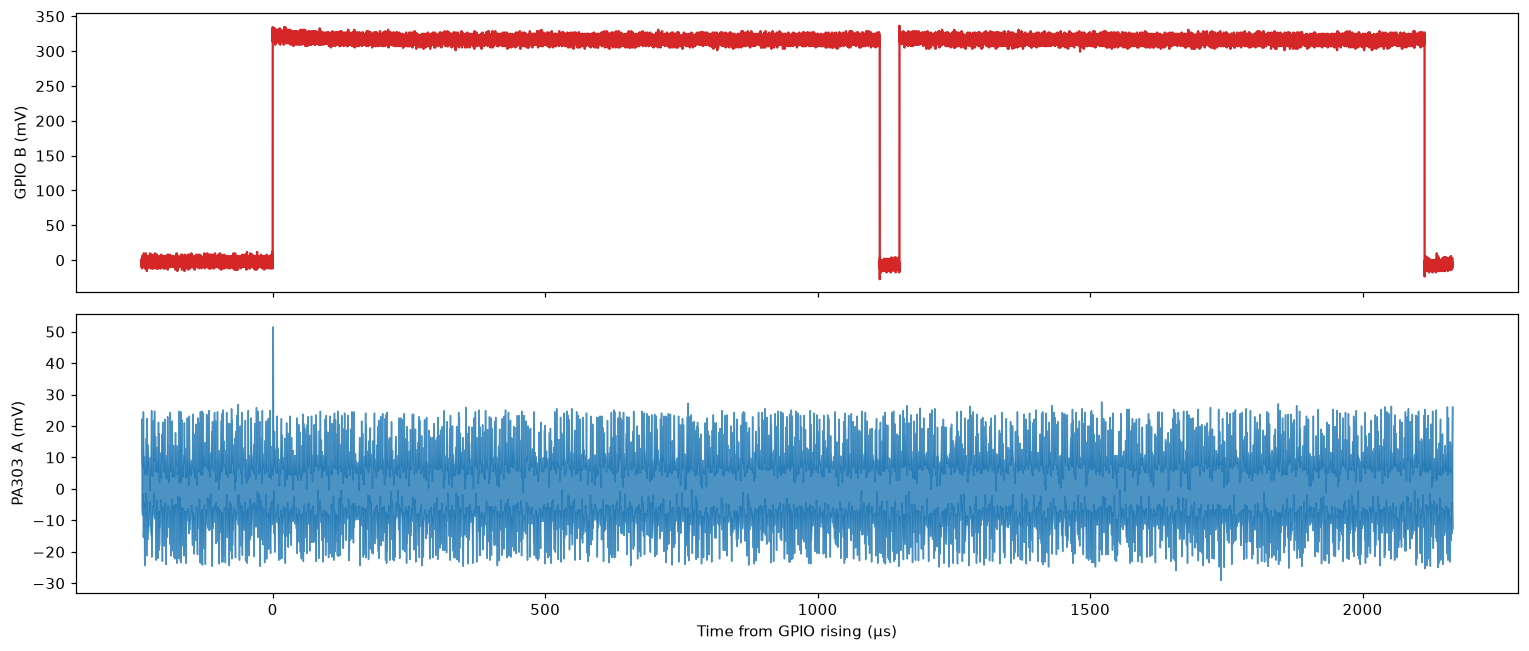

In [5]:
display(EXPERIMENT['widths'].describe().round(3))
print(
    f"AES mean {EXPERIMENT['aes_mean_us']:.3f} µs, "
    f"SHA mean {EXPERIMENT['sha_mean_us']:.3f} µs, "
    f"간격 {EXPERIMENT['width_gap_us']:.3f} µs, "
    f"분리 {EXPERIMENT['separable']}, midpoint {EXPERIMENT['midpoint_us']:.3f} µs"
)
ex = EXPERIMENT['width_examples'][0]
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(ex['time_us'], ex['b_mv'], color='#d62728')
axes[0].set_ylabel('GPIO B (mV)')
t, lo, hi = envelope_xy(ex['time_us'], ex['a_mv'])
axes[1].fill_between(t, lo, hi, color='#1f77b4', alpha=0.8)
axes[1].set_ylabel('PA303 A (mV)')
axes[1].set_xlabel('Time from GPIO rising (µs)')
fig.tight_layout()
plt.show()


## 5. pulse-width qualifier가 남긴 B 펄스 개수

sha_only는 짧은 펄스 끝에서 열리므로 B HIGH가 하나여야 한다. aes_only는 긴 펄스
끝(AES falling)에서 열리고, 창이 SHA까지 담으면 HIGH가 둘이다. 창을 AES만
남기게 줄이지 않는 한 둘은 버그가 아니라 창 길이다.


,qualifier,n,mean_b_pulses,min_b_pulses,max_b_pulses,error
0,aes_only,5,2.0,2,2,
1,sha_only,5,1.0,1,1,


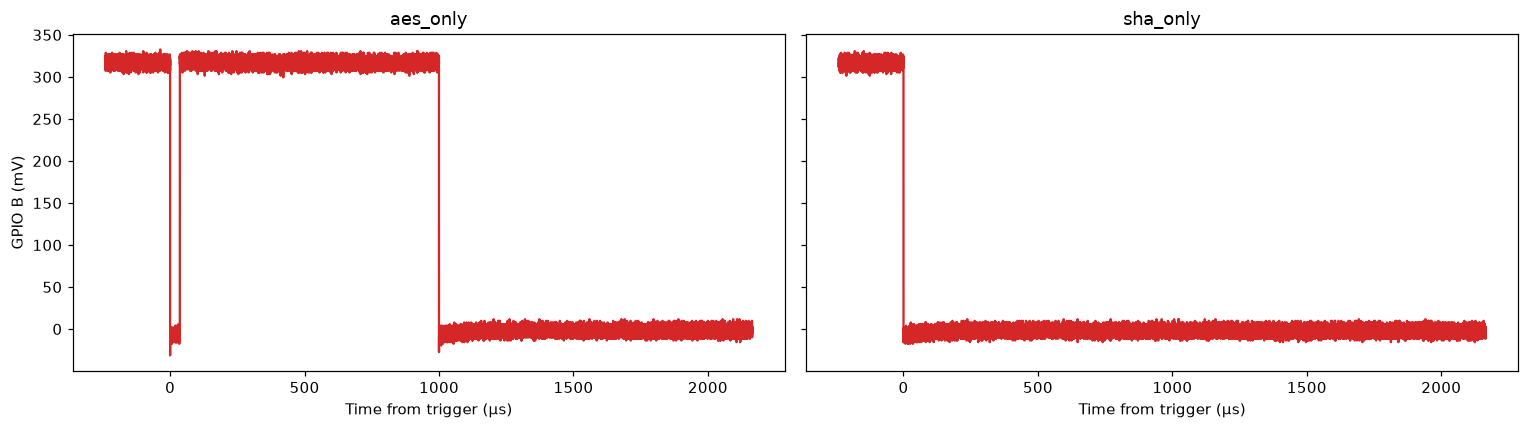

In [6]:
rows = []
for name, recs in EXPERIMENT['pw_captures'].items():
    err = EXPERIMENT['pw_errors'].get(name, '')
    if not recs:
        rows.append({'qualifier': name, 'n': 0, 'mean_b_pulses': np.nan, 'error': err or 'no captures'})
        continue
    n_pulses = [rec.get('n_b_pulses') for rec in recs]
    rows.append({
        'qualifier': name,
        'n': len(recs),
        'mean_b_pulses': float(np.mean(n_pulses)),
        'min_b_pulses': int(np.min(n_pulses)),
        'max_b_pulses': int(np.max(n_pulses)),
        'error': err,
    })
display(pd.DataFrame(rows))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, name in zip(axes, ('aes_only', 'sha_only')):
    recs = EXPERIMENT['pw_captures'][name]
    ax.set_title(name)
    if not recs:
        ax.text(0.5, 0.5, EXPERIMENT['pw_errors'].get(name, 'no capture'), ha='center', va='center', transform=ax.transAxes)
        continue
    rec = recs[0]
    ax.plot(rec['time_us'], rec['b_mv'], color='#d62728')
    ax.set_xlabel('Time from trigger (µs)')
axes[0].set_ylabel('GPIO B (mV)')
fig.tight_layout()
plt.show()


## 6. analog window vs GPIO 에지

B는 검증용으로 켜 두었으므로 analog가 연 창에서 GPIO 상승이 몇 개인지 잰다.
t=0이 analog EXIT다. GPIO 2개이고 첫 상승이 0 근처면 EM 창이 GPIO와 같은 사건을 본 것이다.
GPIO가 0개면 창이 암호 EM만으로 열렸고, 그 캡처 안에는 트리거 펄스가 없다.
고정 입력에서도 0개가 나오면 진폭 트리거의 입력 의존이다.


analog error: (none)


,first_gpio_us,second_gpio_us,n_pulses,note
0,NaN,NaN,0,Pico B에서 유효한 트리거 펄스 2개가 필요하지만 0개를 검출했습니다.
1,-240.555,36.163,2,NaN
2,NaN,NaN,0,Pico B에서 유효한 트리거 펄스 2개가 필요하지만 0개를 검출했습니다.
3,NaN,NaN,0,Pico B에서 유효한 트리거 펄스 2개가 필요하지만 0개를 검출했습니다.
4,NaN,NaN,0,Pico B에서 유효한 트리거 펄스 2개가 필요하지만 0개를 검출했습니다.


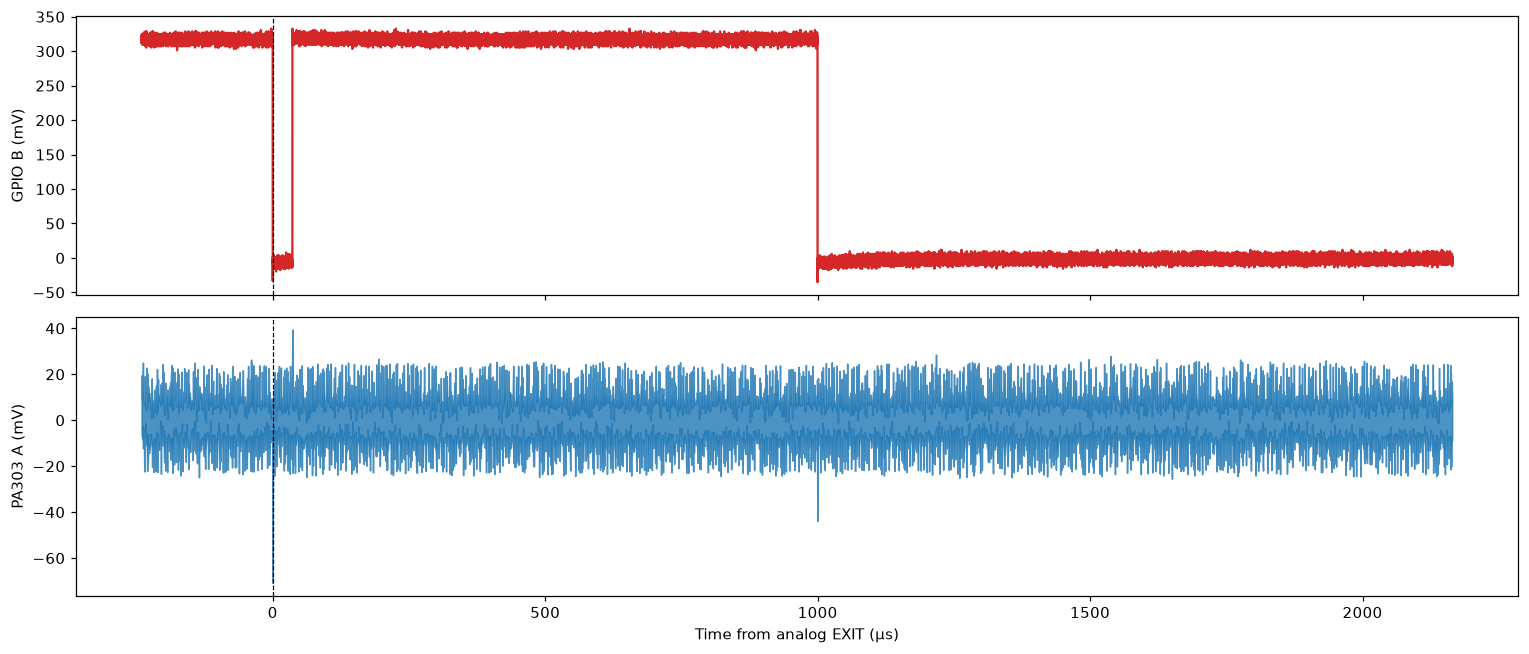

In [7]:
print('analog error:', EXPERIMENT['analog_error'] or '(none)')
rows = []
for rec in EXPERIMENT['analog_captures']:
    if rec['b_mv'] is None:
        continue
    try:
        pulses = detect_trigger_pulses(rec['time_us'], rec['b_mv'])
        rows.append({
            'first_gpio_us': pulses[0][0],
            'second_gpio_us': pulses[1][0],
            'n_pulses': 2,
        })
    except Exception as exc:
        high = rec['b_mv'] >= PICO_TRIGGER_THRESHOLD_MV
        n = int(np.sum(np.diff(high.astype(np.int8), prepend=0) == 1))
        rows.append({'first_gpio_us': np.nan, 'second_gpio_us': np.nan, 'n_pulses': n, 'note': str(exc)})
if rows:
    analog_table = pd.DataFrame(rows)
    display(analog_table.round(3))
    best = int(analog_table['n_pulses'].astype(int).idxmax())
    rec = EXPERIMENT['analog_captures'][best]
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(rec['time_us'], rec['b_mv'], color='#d62728')
    axes[0].axvline(0.0, color='k', linestyle='--', linewidth=0.8)
    axes[0].set_ylabel('GPIO B (mV)')
    t, lo, hi = envelope_xy(rec['time_us'], rec['a_mv'])
    axes[1].fill_between(t, lo, hi, color='#1f77b4', alpha=0.8)
    axes[1].axvline(0.0, color='k', linestyle='--', linewidth=0.8)
    axes[1].set_ylabel('PA303 A (mV)')
    axes[1].set_xlabel('Time from analog EXIT (µs)')
    fig.tight_layout()
    plt.show()
else:
    print('analog window 캡처가 없습니다.')


## 7. trigger delay

첫 GPIO 상승 뒤 `delay_samples`만큼 기다려 캡처를 시작한다. delay는 AES 끝에
가깝게 두고, 프리트리거 10%가 AES 꼬리를 남기면 B HIGH는 둘이 된다.
앞 펄스가 음수 시각, 뒤 펄스가 AES-SHA 간격(~36 µs)이면 delay는 의도대로다.


delay error: (none)
delay_samples: 22460


,n_pulses,first_us,second_us
0,2,-117.051,36.163
1,2,-117.051,36.163
2,2,-117.051,36.163
3,2,-117.051,36.163
4,2,-117.051,36.163


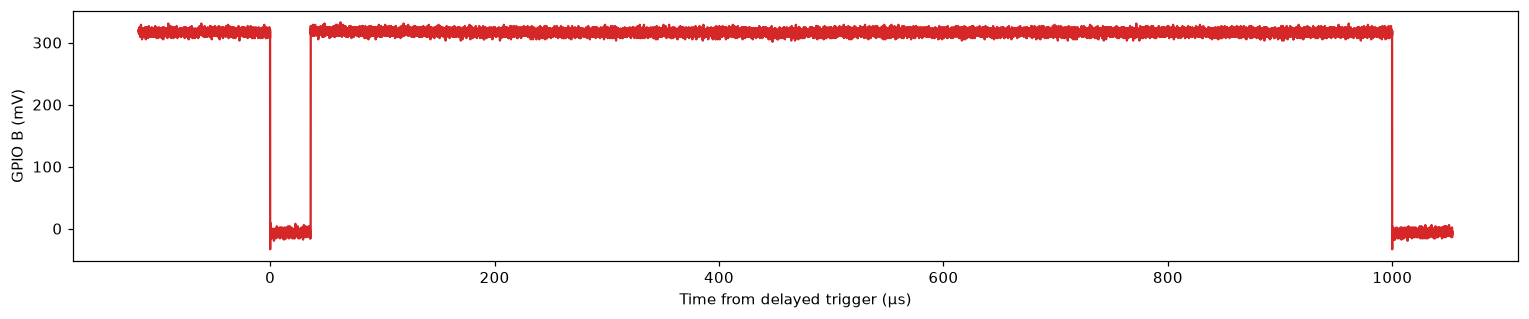

In [8]:
print('delay error:', EXPERIMENT['delay_error'] or '(none)')
print('delay_samples:', EXPERIMENT['delay_samples'])
rows = []
for rec in EXPERIMENT['delay_captures']:
    try:
        pulses = detect_trigger_pulses(rec['time_us'], rec['b_mv'])
        rows.append({'n_pulses': 2, 'first_us': pulses[0][0], 'second_us': pulses[1][0]})
    except Exception:
        high = rec['b_mv'] >= PICO_TRIGGER_THRESHOLD_MV
        n = int(np.sum(np.diff(high.astype(np.int8), prepend=0) == 1))
        rows.append({'n_pulses': n, 'first_us': np.nan, 'second_us': np.nan})
if rows:
    display(pd.DataFrame(rows).round(3))
    rec = EXPERIMENT['delay_captures'][0]
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(rec['time_us'], rec['b_mv'], color='#d62728')
    ax.set_xlabel('Time from delayed trigger (µs)')
    ax.set_ylabel('GPIO B (mV)')
    fig.tight_layout()
    plt.show()
else:
    print('delay 캡처가 없습니다.')


## 해석 지침

- 폭 표의 간격이 5 µs 미만이면 이 펌웨어의 AES·SHA HIGH는 hardware qualifier로 안 갈린다.
  펌웨어를 고쳐 폭을 벌리는 것은 Pico 노트북이 아니다.
- sha_only는 SHA(짧음)만 B HIGH 하나여야 한다. aes_only는 AES falling 뒤에 SHA가
  같은 창에 남으면 HIGH가 둘이다. 예전 USB 사망은 음 펄스 대기 + auto-trigger=0
  무한 `IsReady`였다. 양 펄스와 psospa 4인자 ABI로 고쳤다.
- analog 5회 중 GPIO 0개가 있으면 EM EXIT가 GPIO와 무관한 버스트로 열린 것이다.
  고정 입력만 썼으므로 무작위 평문 편향은 주장하지 않는다.
- delay 창의 B HIGH 둘과 음수 시각의 첫 펄스는 10% 프리트리거의 AES 꼬리다.
  SHA만 보려면 프리트리거를 더 줄이거나 창을 더 짧게 한다.
- Dataset·CPA는 이 노트북의 범위가 아니다.
